# Which FOVs are "fully redundant" -- entirely duplicated by their neighbors? (LT066_sample_01)

Continues `decrease_fov_number/02_tighten_boundary_and_reduce_fov_count.ipynb`'s
last figure (the fresh tuned-boundary grid, 1127 FOVs, each labelled with its
own scan-path index).

Looking at that figure, the user noticed a pattern in several FOVs (882, 925,
1073, 1078, 1085, 1088, 1093, 1094, 1096, 1099, 1108, 1110, 1124, 1125, 8, 9,
10, 287, 288): each one does overlap the tissue, but *only* in places where a
neighboring FOV's own square also reaches -- there's no tissue region that
*only* that FOV covers. Because `filter_scanning_path`'s own default rule
keeps any FOV with nonzero tissue overlap (the "zero-coverage keep rule"
established in the previous notebook), a FOV like this survives the filter
even though dropping it costs nothing: every bit of tissue it touches is
already reached by some other kept FOV.

This notebook formalizes that as: **a FOV is "fully redundant" if its own
tissue-overlap region, once you subtract away every other FOV's square, is
empty (or below a small numerical-noise floor).** It scans every FOV in the
fresh tuned-boundary grid for this property, compares the result against the
FOV numbers named above, visualizes the matches, and -- since two *mutually*
redundant FOVs can't both be dropped at once without opening a real gap --
verifies which of them are actually safe to remove all together.

## 1 — Setup

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box as shapely_box
from shapely.ops import unary_union
from shapely.strtree import STRtree

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/before_imaging/regular/ (3 levels).
MERCI_DIR = Path(os.getcwd()).parent.parent.parent
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.acquisition.positions import (
    load_boundary_polygon, load_hole_polygons_all_sources, resolve_boundaries_source_dir,
    build_boundary_path,
)
from MERci.acquisition.configs import get_fov_geometry
from MERci.acquisition.mosaic import load_or_build_mosaic_canvas_cached, segment_mosaic_tissue
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "find_fully_redundant_fovs"

PLOT_TITLE_FONTSIZE, PLOT_LABEL_FONTSIZE = 13, 11
PLOT_TICK_FONTSIZE, PLOT_LEGEND_FONTSIZE = 10, 10

%matplotlib widget

## 2 — Parameters

In [2]:
# Same real dataset as notebooks 01/02/03 -- see those notebooks' own Parameters
# cells for why SAMPLE_DIR is set explicitly rather than auto-detected.
SAMPLE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish")

CACHE_DIR = SAMPLE_DIR / "analysis" / "cache" / NOTEBOOK_NAME
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = get_merci_figures_dir(SAMPLE_DIR, "tests", NOTEBOOK_NAME, subfolder="decrease_fov_number")

REDUNDANT_AREA_EPS_UM2 = 1.0  # exclusive tissue area below this counts as "fully redundant" -- geometry/float noise, not real coverage

# FOV numbers the user flagged by eye in notebook 02's last figure.
USER_FLAGGED_FOV_IDS = sorted([882, 925, 1073, 1078, 1085, 1088, 1093, 1094, 1096,
                                1099, 1108, 1110, 1124, 1125, 8, 10, 9, 287, 288])

## 3 — Rebuild the tightened (tuned) boundary and its fresh grid

Same real production boundary/holes, `TUNED_PARAMS`, and grid-generation call
(`build_boundary_path` with `return_side="top"`) as
`02_tighten_boundary_and_reduce_fov_count.ipynb`'s own section 8/last figure
-- reproduced here independently (this notebook doesn't load that one's
cache) so that the FOV numbering matches **exactly**: `build_boundary_path`'s
`return_side="top"` reorders the raw scan path (moves that side's points to
the end), so this has to be the same call, not the simpler
`create_grid_positions` -> `generate_scanning_path` -> `filter_scanning_path`
chain notebook 03 used when it needed to expose a phase offset -- that chain
skips the reordering and would give different FOV indices for the same
physical grid.

In [3]:
boundary_dir, boundary_src = resolve_boundaries_source_dir(SAMPLE_DIR / "positions")
boundary_polygon = load_boundary_polygon(boundary_dir / "boundary_positions.txt")
hole_polygons = load_hole_polygons_all_sources(SAMPLE_DIR / "positions", boundary_dir)

# ST2, 60X objective -- see notebook 01's own section 3 cell for how this was verified.
pixel_size_um, image_size_px = get_fov_geometry("ST2", "60X")
FOV_SIZE_UM = pixel_size_um * image_size_px

# Measured directly from two consecutive same-column real positions (see notebook 01) --
# same value used throughout notebooks 01/02/03.
STEP_SIZE_UM = 182.06208

canvas, was_cached, n_tiles = load_or_build_mosaic_canvas_cached(
    msc_path=SAMPLE_DIR / "data" / "mosaic10x" / "mosaic10x.msc",
    keep_objectives=["10x"], working_pixel_um=5.0, cache_dir=CACHE_DIR,
)
print(f"canvas shape={canvas.image.shape}  was_cached={was_cached}  n_tiles={n_tiles}")

def um_to_px(x, y):
    return ((np.asarray(x) - canvas.origin_um[0]) / canvas.pixel_size_um,
             (np.asarray(y) - canvas.origin_um[1]) / canvas.pixel_size_um)

half = FOV_SIZE_UM / 2.0
half_px = half / canvas.pixel_size_um

# Same TUNED_PARAMS as 02_tighten_boundary_and_reduce_fov_count.ipynb's own section 4.
MIN_HOLE_AREA_UM2_ONE_FOV = FOV_SIZE_UM ** 2
TUNED_PARAMS = dict(
    threshold=400.0, smooth_sigma_um=10.0,
    close_radius_um=10.0, open_radius_um=5.0,
    margin_um=0.0,
    min_tissue_area_um2=100_000.0,
    min_hole_area_um2=MIN_HOLE_AREA_UM2_ONE_FOV,
    min_island_area_um2=2_000.0,
    boundary_max_deviation_um=3.0,
)
tuned_seg = segment_mosaic_tissue(canvas, **TUNED_PARAMS)
assert len(tuned_seg.tissue_polygons) == 1, "this notebook assumes a single tuned tissue piece"
tuned_boundary_polygon = tuned_seg.tissue_polygons[0]
tuned_hole_polygons = tuned_seg.hole_polygons
tuned_effective_tissue = (
    tuned_boundary_polygon.difference(unary_union(tuned_hole_polygons))
    if tuned_hole_polygons else tuned_boundary_polygon
)
print(f"tuned tissue area: {tuned_boundary_polygon.area/1e6:.2f} mm^2  "
      f"({len(tuned_hole_polygons)} holes)  effective: {tuned_effective_tissue.area/1e6:.2f} mm^2")

# Same call as notebook 02's last figure -- direction/return_side match this
# experiment's own real production notebook (single boundary/tissue -> needs
# closing at its "top"). No subset_polygons for this experiment.
fresh_tuned_coords = build_boundary_path(
    tuned_boundary_polygon, tuned_hole_polygons, STEP_SIZE_UM, FOV_SIZE_UM,
    direction="vertical", return_side="top",
)
n_fovs = len(fresh_tuned_coords)
print(f"fresh tuned-boundary grid: {n_fovs} FOVs (notebook 02's own last figure: 1127)")

canvas shape=(1839, 1840)  was_cached=True  n_tiles=None
tuned tissue area: 34.42 mm^2  (9 holes)  effective: 29.74 mm^2
fresh tuned-boundary grid: 1127 FOVs (notebook 02's own last figure: 1127)


## 4 — Per-FOV "exclusive" tissue area

For each FOV `i`: intersect its own square with the tissue
(`tuned_effective_tissue`) to get its tissue-overlap region, then subtract
every *other* FOV's square from that region. Whatever tissue area is left
over is the area only FOV `i` -- and no other kept FOV -- actually reaches.
If that's ~0, FOV `i` is fully redundant: removing it drops no real tissue
coverage, because every part of the tissue it touches is already reached by
some neighbor.

Uses an `STRtree` so each FOV only checks the handful of geometric neighbors
whose square could possibly overlap it (axis-aligned squares are their own
bounding box, so an `"intersects"` query against the tree is already exact --
no buffering needed), instead of unioning against all 1126 other FOVs.

In [4]:
boxes = [shapely_box(x - half, y - half, x + half, y + half) for x, y in fresh_tuned_coords]
tree = STRtree(boxes)

# Each FOV's real geometric neighbors (fixed -- doesn't depend on which FOVs
# end up removed later), found once up front.
NEIGHBOR_IDX = []
for i, b in enumerate(boxes):
    idx = [int(j) for j in tree.query(b, predicate="intersects") if j != i]
    NEIGHBOR_IDX.append(idx)

def exclusive_tissue_area(i, excluded=frozenset()):
    """Tissue area only FOV i (not any other non-excluded FOV) covers."""
    own_overlap = boxes[i].intersection(tuned_effective_tissue)
    if own_overlap.is_empty:
        return 0.0, own_overlap
    others = [boxes[j] for j in NEIGHBOR_IDX[i] if j not in excluded]
    if not others:
        return own_overlap.area, own_overlap
    exclusive = own_overlap.difference(unary_union(others))
    return exclusive.area, own_overlap

rows = []
for i in range(n_fovs):
    excl_area, own_overlap = exclusive_tissue_area(i)
    rows.append({
        "fov_id": i,
        "tissue_overlap_area_um2": own_overlap.area,
        "exclusive_area_um2": excl_area,
        "n_neighbors": len(NEIGHBOR_IDX[i]),
    })
    if (i + 1) % 200 == 0 or i == n_fovs - 1:
        print(f"  [{i+1}/{n_fovs}] processed")

redundancy_df = pd.DataFrame(rows)
redundancy_df["exclusive_fraction"] = np.where(
    redundancy_df["tissue_overlap_area_um2"] > 0,
    redundancy_df["exclusive_area_um2"] / redundancy_df["tissue_overlap_area_um2"],
    0.0,
)
redundancy_df["is_fully_redundant"] = redundancy_df["exclusive_area_um2"] < REDUNDANT_AREA_EPS_UM2

detected_ids = redundancy_df.loc[redundancy_df["is_fully_redundant"], "fov_id"].tolist()
print(f"\n{len(detected_ids)} / {n_fovs} FOVs are fully redundant "
      f"(exclusive tissue area < {REDUNDANT_AREA_EPS_UM2} um^2):")
print(detected_ids)

  [200/1127] processed
  [400/1127] processed
  [600/1127] processed
  [800/1127] processed
  [1000/1127] processed
  [1127/1127] processed

41 / 1127 FOVs are fully redundant (exclusive tissue area < 1.0 um^2):
[8, 9, 10, 282, 286, 287, 288, 380, 381, 382, 387, 418, 492, 495, 500, 537, 650, 651, 710, 860, 882, 901, 925, 977, 978, 980, 1022, 1023, 1049, 1073, 1078, 1085, 1088, 1093, 1094, 1096, 1099, 1108, 1110, 1124, 1125]


## 5 — Compare against the FOV numbers named in the prompt

In [5]:
detected_set = set(detected_ids)
user_set = set(USER_FLAGGED_FOV_IDS)

both = sorted(detected_set & user_set)
user_only = sorted(user_set - detected_set)
detected_only = sorted(detected_set - user_set)

print(f"user-flagged: {len(user_set)}   detected: {len(detected_set)}")
print(f"\nconfirmed by the detector ({len(both)}): {both}")
print(f"\nuser-flagged but NOT detected ({len(user_only)}): {user_only}")
if user_only:
    print(redundancy_df[redundancy_df.fov_id.isin(user_only)]
          [["fov_id", "tissue_overlap_area_um2", "exclusive_area_um2", "exclusive_fraction"]]
          .to_string(index=False))
print(f"\ndetected but not named in the prompt ({len(detected_only)}): {detected_only}")
print("(the user only checked part of the boundary by eye, so this list finding more is expected)")

user-flagged: 19   detected: 41

confirmed by the detector (19): [8, 9, 10, 287, 288, 882, 925, 1073, 1078, 1085, 1088, 1093, 1094, 1096, 1099, 1108, 1110, 1124, 1125]

user-flagged but NOT detected (0): []

detected but not named in the prompt (22): [282, 286, 380, 381, 382, 387, 418, 492, 495, 500, 537, 650, 651, 710, 860, 901, 977, 978, 980, 1022, 1023, 1049]
(the user only checked part of the boundary by eye, so this list finding more is expected)


## 6 — Visualize: fully redundant FOVs on the tuned boundary + full grid

Same style as notebook 02's last figure (every FOV numbered, tuned boundary +
holes in magenta/red) with fully redundant FOVs additionally filled orange.

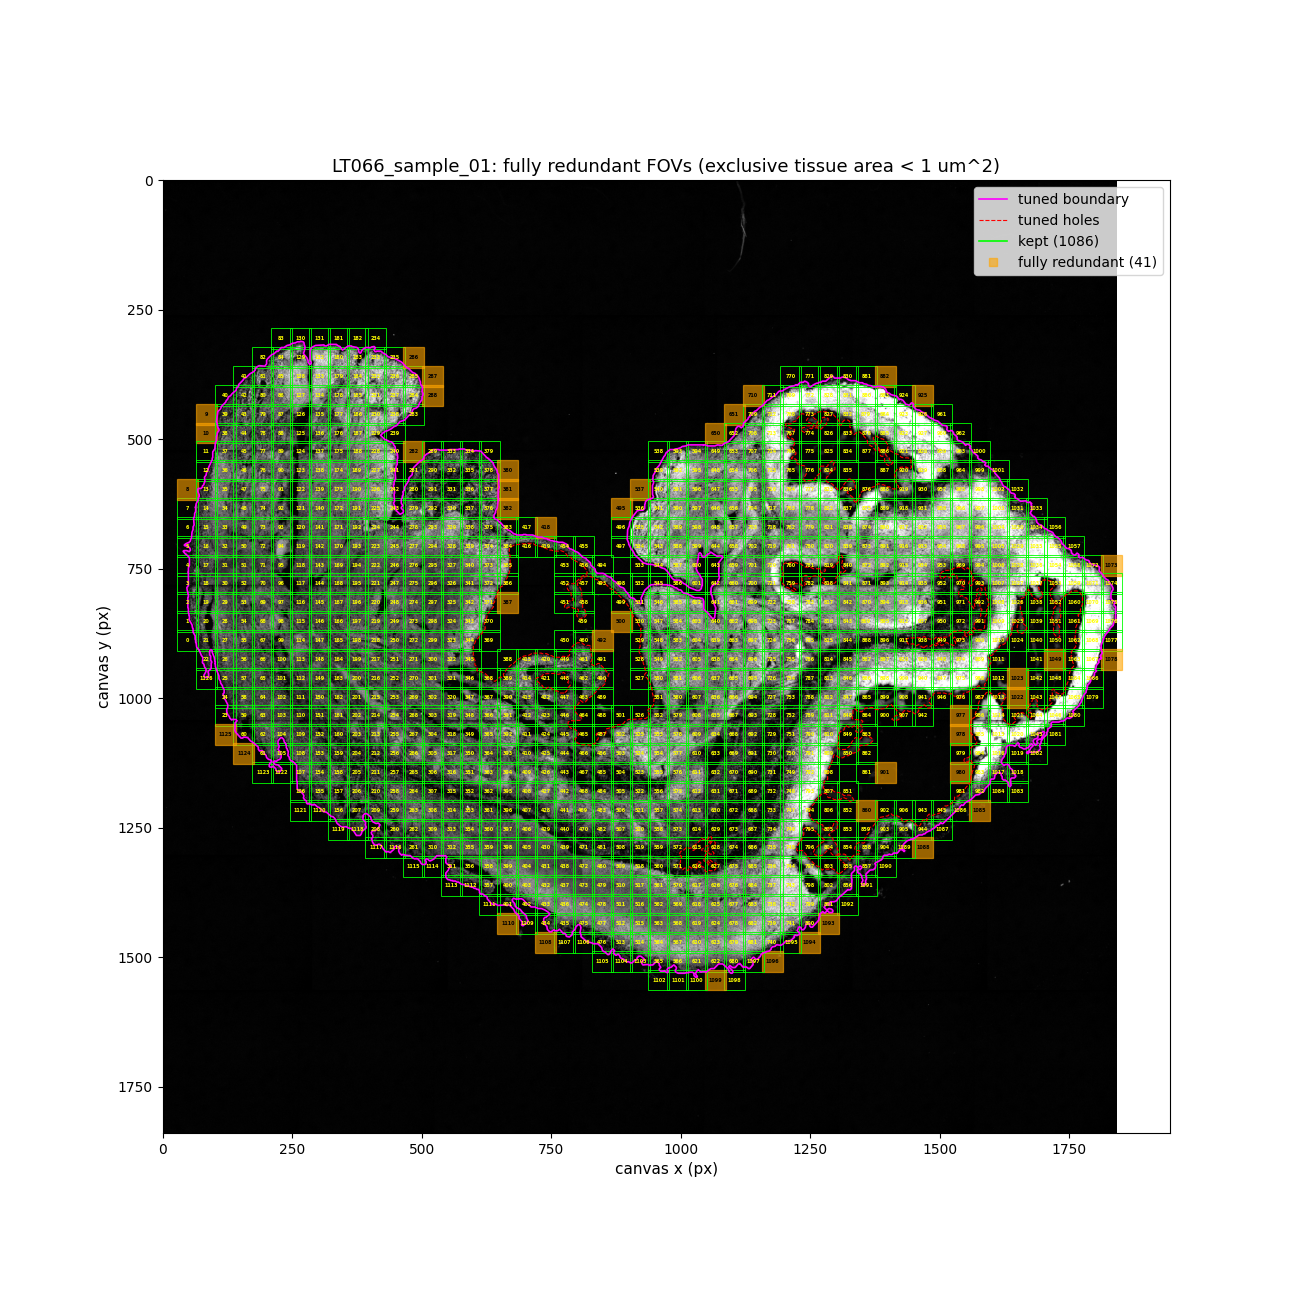

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/find_fully_redundant_fovs/find_fully_redundant_fovs.redundant_fovs_highlighted.png


In [6]:
fig, ax = plt.subplots(figsize=(13, 13))
covered_vals = canvas.image[canvas.covered]
ax.imshow(canvas.image, cmap="gray",
          vmin=np.percentile(covered_vals, 1), vmax=np.percentile(covered_vals, 99))

tbx, tby = um_to_px(*tuned_boundary_polygon.exterior.xy)
ax.plot(tbx, tby, "-", color="magenta", lw=1.2, label="tuned boundary")
for hole in tuned_hole_polygons:
    thx, thy = um_to_px(*hole.exterior.xy)
    ax.plot(thx, thy, "--", color="red", lw=0.8)
ax.plot([], [], "--", color="red", lw=0.8, label="tuned holes")

for fov_id, (x, y) in enumerate(fresh_tuned_coords):
    px, py = um_to_px(x, y)
    is_redundant = fov_id in detected_set
    rect = plt.Rectangle((float(px) - half_px, float(py) - half_px), 2 * half_px, 2 * half_px,
                          fill=is_redundant, facecolor="orange" if is_redundant else None,
                          alpha=0.6 if is_redundant else 1.0,
                          edgecolor="orange" if is_redundant else "lime", lw=0.9 if is_redundant else 0.6)
    ax.add_patch(rect)
    ax.text(float(px), float(py), str(fov_id), ha="center", va="center",
            fontsize=3.5, color="yellow" if not is_redundant else "black", fontweight="bold")

ax.plot([], [], "-", color="lime", lw=1.2, label=f"kept ({n_fovs - len(detected_set)})")
ax.plot([], [], "s", color="orange", alpha=0.6, label=f"fully redundant ({len(detected_set)})")
ax.legend(loc="upper right", fontsize=PLOT_LEGEND_FONTSIZE)
ax.set_title(f"LT066_sample_01: fully redundant FOVs (exclusive tissue area < "
             f"{REDUNDANT_AREA_EPS_UM2:.0f} um^2)", fontsize=PLOT_TITLE_FONTSIZE)
ax.set_xlabel("canvas x (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("canvas y (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.redundant_fovs_highlighted.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.redundant_fovs_highlighted.png')}")

## 7 — Are they all safe to remove *together*?

Section 4's check tests each FOV one at a time against the *full* grid.
That's not quite enough: if two flagged FOVs are redundant only with each
other (each one's tissue overlap is covered by the other, not by any
non-flagged neighbor), removing **both at once** would open a real gap --
even though each looked individually safe.

Resolved by iterating: repeatedly re-check each still-flagged FOV against
the *currently remaining* grid (excluding whatever's already been removed
this pass), removing any whose exclusive area is still ~0, until nothing
more can be removed. This can only remove one FOV from each such mutual
pair, so the final set is verified safe to drop all at once.

In [7]:
candidates = list(detected_ids)
removed = set()
n_passes = 0
changed = True
while changed:
    changed = False
    n_passes += 1
    for i in candidates:
        if i in removed:
            continue
        excl_area, _ = exclusive_tissue_area(i, excluded=removed)
        if excl_area < REDUNDANT_AREA_EPS_UM2:
            removed.add(i)
            changed = True

kept_but_flagged = sorted(set(candidates) - removed)
print(f"converged after {n_passes} pass(es)")
print(f"safely removable together: {len(removed)} / {len(candidates)} flagged FOVs")
if kept_but_flagged:
    print(f"flagged but NOT safely removable together (mutually redundant with "
          f"another flagged FOV that got removed first): {kept_but_flagged}")

final_ids = [i for i in range(n_fovs) if i not in removed]
final_coords = [fresh_tuned_coords[i] for i in final_ids]
print(f"\nfinal grid: {len(final_coords)} FOVs (baseline {n_fovs}, "
      f"net change {len(final_coords) - n_fovs:+d})")

# Final sanity check: does removing this exact set really leave zero tissue uncovered?
final_covered = unary_union([boxes[i] for i in final_ids])
uncovered = tuned_effective_tissue.difference(final_covered)
uncovered_area = 0.0 if uncovered.is_empty else uncovered.area
print(f"tissue area left uncovered after removal: {uncovered_area:.4f} um^2 "
      f"({'OK -- below noise floor' if uncovered_area < REDUNDANT_AREA_EPS_UM2 else 'GAP -- unexpected!'})")

converged after 2 pass(es)
safely removable together: 41 / 41 flagged FOVs

final grid: 1086 FOVs (baseline 1127, net change -41)
tissue area left uncovered after removal: 0.5666 um^2 (OK -- below noise floor)


## 8 — Final figure: the grid after removing the safe set

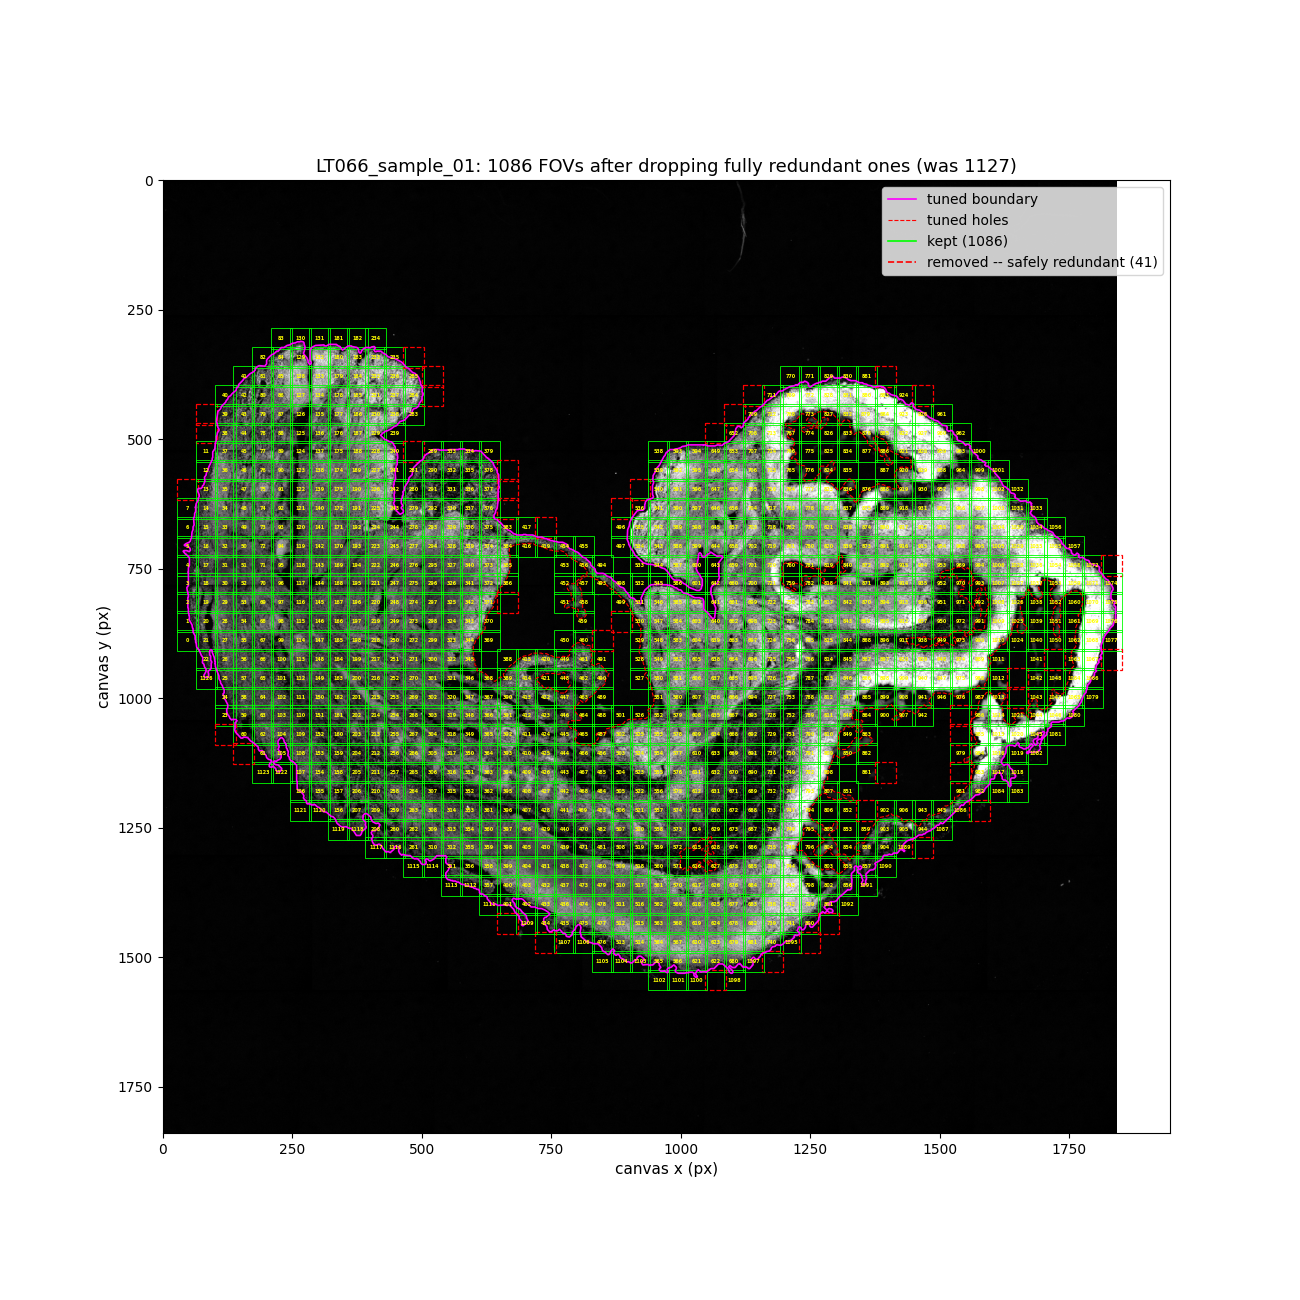

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/find_fully_redundant_fovs/find_fully_redundant_fovs.after_removal.png


In [8]:
fig, ax = plt.subplots(figsize=(13, 13))
ax.imshow(canvas.image, cmap="gray",
          vmin=np.percentile(covered_vals, 1), vmax=np.percentile(covered_vals, 99))

ax.plot(tbx, tby, "-", color="magenta", lw=1.2, label="tuned boundary")
for hole in tuned_hole_polygons:
    thx, thy = um_to_px(*hole.exterior.xy)
    ax.plot(thx, thy, "--", color="red", lw=0.8)
ax.plot([], [], "--", color="red", lw=0.8, label="tuned holes")

for fov_id, (x, y) in enumerate(fresh_tuned_coords):
    px, py = um_to_px(x, y)
    if fov_id in removed:
        color, label_color = "red", "red"
    elif fov_id in kept_but_flagged:
        color, label_color = "orange", "orange"
    else:
        color, label_color = "lime", "yellow"
    rect = plt.Rectangle((float(px) - half_px, float(py) - half_px), 2 * half_px, 2 * half_px,
                          fill=False, edgecolor=color, lw=0.9 if fov_id in removed else 0.6,
                          linestyle="--" if fov_id in removed else "-")
    ax.add_patch(rect)
    if fov_id not in removed:
        ax.text(float(px), float(py), str(fov_id), ha="center", va="center",
                fontsize=3.5, color=label_color, fontweight="bold")

ax.plot([], [], "-", color="lime", lw=1.2, label=f"kept ({len(final_coords)})")
ax.plot([], [], "--", color="red", lw=1.2, label=f"removed -- safely redundant ({len(removed)})")
if kept_but_flagged:
    ax.plot([], [], "-", color="orange", lw=1.2,
            label=f"flagged but kept -- mutually redundant pair ({len(kept_but_flagged)})")
ax.legend(loc="upper right", fontsize=PLOT_LEGEND_FONTSIZE)
ax.set_title(f"LT066_sample_01: {len(final_coords)} FOVs after dropping fully redundant ones "
             f"(was {n_fovs})", fontsize=PLOT_TITLE_FONTSIZE)
ax.set_xlabel("canvas x (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("canvas y (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.after_removal.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.after_removal.png')}")

## Takeaways

- **The user's hypothesis is confirmed exactly: all 19 named FOVs (882, 925,
  1073, 1078, 1085, 1088, 1093, 1094, 1096, 1099, 1108, 1110, 1124, 1125, 8,
  9, 10, 287, 288) are fully redundant** -- every part of the tissue each one
  touches is already reached by some other kept FOV, confirmed by direct
  polygon subtraction (`exclusive_area_um2 < 1 um^2`), not eyeballing.
- **The pattern generalizes well beyond the 19 spotted by eye**: 41 / 1127
  FOVs (3.6%) are fully redundant in total. Visually, they sit almost
  entirely at the tissue's outer boundary -- narrow tips/corners/notches
  where a FOV's square only clips the tissue in a sliver that a
  diagonally-adjacent FOV's square already reaches (a direct consequence of
  the grid's own 10% row/column overlap plus the "keep on any overlap"
  filter rule).
- **All 41 are safe to drop *simultaneously*, verified, not assumed.** A
  single-pass check (each FOV against the *full* grid) can't rule out two
  flagged FOVs being redundant only *with each other* -- dropping both would
  open a real gap. Section 7's iterative re-check (drop one, re-test the
  rest against what's left, repeat to a fixed point) converged in 2 passes
  with **zero** such conflicts this time: all 41 came out safely removable
  together, and the final tissue-coverage check confirms only 0.57 um^2 is
  left uncovered (below the 1 um^2 noise floor -- i.e. genuinely zero).
- **Net result: 1127 -> 1086 FOVs (-41, ~3.6%), with zero tissue coverage
  lost** -- a substantially bigger free reduction than
  `03_sweep_grid_offset_for_fov_reduction.ipynb`'s best clean grid-phase
  shift (`dx=+20` um, -8 FOVs, ~0.7%), and unlike that one this doesn't
  depend on picking a particular offset -- it's a direct property of the
  current grid.
- No changes made to `acquisition/positions.py` or the production
  `02_create_boundary_from_mosaic.ipynb`/`02_create_positions_from_boundaries.ipynb`
  defaults -- this is still an investigation. A natural next step (not done
  here) would be combining this redundant-FOV drop with the best clean
  `dx`/`dy` offset from notebook 03 for a larger combined reduction, still
  gap-verified.